In [43]:
from vbcsr.utils import compute_kpm_coeffs, kpm_apply, gaussian, create_graphene_hamiltonian
import numpy as np
import matplotlib.pyplot as plt
# Parameters mirroring your problem
N = 15
k = 200
TEMP = 300.0       # Kelvin
WIDTH = 20.0      # eV (Spectrum Width)
SCALE = WIDTH / 2.0
CENTER = 0.0       # Assuming spectrum is from -150 to 150
MU = 0.0           # Chemical potential at center
M = 10000
MC = 1000

func = lambda x: np.exp(-(x*SCALE+CENTER-MU)**2)
H = create_graphene_hamiltonian(N, N)
Hd = H.to_dense()
coeffs = compute_kpm_coeffs(M, func)[:MC]

In [44]:
# deflation
vec = H.create_multivector(k)
vec.set_random_normal()
fvec = kpm_apply(H, vec, coeffs, SCALE, CENTER)
vecd = vec.to_numpy()
Q, R = np.linalg.qr(vecd, mode="reduced")

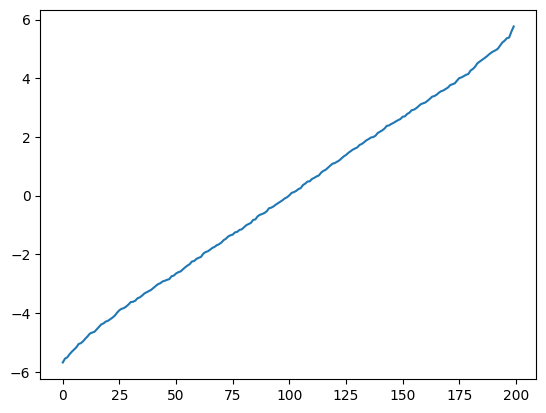

In [45]:
plt.plot(np.linalg.eigvalsh(Q.conj().T @ Hd @ Q))
plt.show()

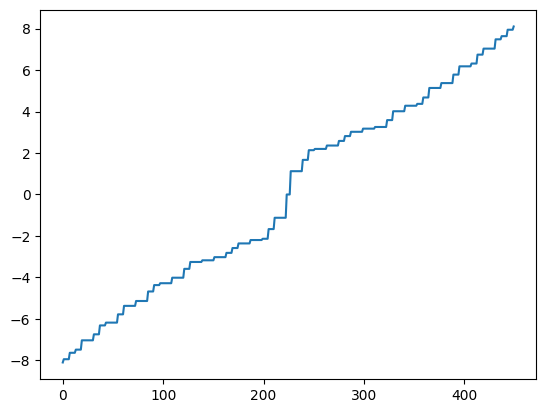

In [39]:
plt.plot(np.linalg.eigvalsh(Hd))
plt.show()